# Optimal Routing with Contraction Hierarchies

This notebook solves the same Empire State Building–to–Central Park routing problem using a **Contraction Hierarchy (CH)**.

CH performs extra work once during preprocessing: it contracts nodes and inserts shortcuts that preserve shortest-path distances. Each later query searches only upward through the hierarchy in both directions, then recursively unpacks shortcuts to recover the original OpenStreetMap route. This makes CH particularly useful when many routes will be queried on the same road network.


In [1]:
# If necessary, run this once and restart the kernel:
# %pip install -U osmnx networkx folium shapely matplotlib

from dataclasses import dataclass
from pathlib import Path
from time import perf_counter
import heapq
import math
import random
import tracemalloc

import matplotlib.pyplot as plt
import networkx as nx
import osmnx as ox

ox.settings.use_cache = True
ox.settings.cache_folder = "osmnx_cache"
ox.settings.requests_timeout = 180


## Download or load the street network


In [2]:
# Coordinates are specified as (latitude, longitude).
origin_point = (40.7484, -73.9857)       # Empire State Building
destination_point = (40.7826, -73.9656)  # Central Park


def haversine_m(lat1, lon1, lat2, lon2):
    """Return the great-circle distance between two coordinates in metres."""
    radius = 6_371_009.0
    phi1, phi2 = math.radians(lat1), math.radians(lat2)
    dphi = math.radians(lat2 - lat1)
    dlambda = math.radians(lon2 - lon1)
    a = (
        math.sin(dphi / 2) ** 2
        + math.cos(phi1) * math.cos(phi2) * math.sin(dlambda / 2) ** 2
    )
    return 2 * radius * math.asin(math.sqrt(a))


center = (
    (origin_point[0] + destination_point[0]) / 2,
    (origin_point[1] + destination_point[1]) / 2,
)
direct_distance = haversine_m(*origin_point, *destination_point)
graph_radius = direct_distance / 2 + 1_200
graph_file = Path("nyc_empire_central_park_drive.graphml")

if graph_file.exists():
    G = ox.io.load_graphml(graph_file)
    print(f"Loaded cached graph: {graph_file}")
else:
    G = ox.graph.graph_from_point(
        center,
        dist=graph_radius,
        network_type="drive",
        simplify=True,
    )
    ox.io.save_graphml(G, graph_file)
    print(f"Downloaded and cached graph: {graph_file}")

origin_id, destination_id = ox.distance.nearest_nodes(
    G,
    X=[origin_point[1], destination_point[1]],
    Y=[origin_point[0], destination_point[0]],
)

print(f"Straight-line POI distance: {direct_distance:,.1f} m")
print(f"Graph radius: {graph_radius:,.1f} m")
print(f"Graph: {len(G.nodes):,} nodes and {len(G.edges):,} edges")
print(f"Origin node: {origin_id}; destination node: {destination_id}")


Downloaded and cached graph: nyc_empire_central_park_drive.graphml
Straight-line POI distance: 4,162.6 m
Graph radius: 3,281.3 m
Graph: 2,170 nodes and 4,549 edges
Origin node: 42446701; destination node: 42433927


## CH arc representation and witness search


In [3]:
@dataclass(frozen=True)
class Arc:
    """A directed original edge or a CH shortcut."""

    u: int
    v: int
    weight: float
    left: int | None = None
    right: int | None = None


def prepare_minimum_edge_graph(G):
    """Keep the shortest parallel OSM edge for each directed node pair."""
    arcs = []
    active_out = {node: {} for node in G.nodes}
    active_in = {node: {} for node in G.nodes}

    for u, v, attributes in G.edges(data=True):
        weight = float(attributes.get("length", 1.0))
        previous_id = active_out[u].get(v)
        if previous_id is None or weight < arcs[previous_id].weight:
            arc_id = len(arcs)
            arcs.append(Arc(u, v, weight))
            active_out[u][v] = arc_id
            active_in[v][u] = arc_id

    return arcs, active_out, active_in


def bounded_witness_search(
    source,
    banned_node,
    cutoff,
    active_nodes,
    active_out,
    arcs,
):
    """Find paths that can witness that proposed shortcuts are unnecessary."""
    distances = {source: 0.0}
    queue = [(0.0, source)]

    while queue:
        distance, node = heapq.heappop(queue)
        if distance != distances.get(node) or distance > cutoff:
            continue

        for neighbor, arc_id in active_out[node].items():
            if neighbor == banned_node or neighbor not in active_nodes:
                continue

            new_distance = distance + arcs[arc_id].weight
            if (
                new_distance <= cutoff
                and new_distance < distances.get(neighbor, math.inf)
            ):
                distances[neighbor] = new_distance
                heapq.heappush(queue, (new_distance, neighbor))

    return distances


## Contraction Hierarchy preprocessing


In [4]:
@dataclass
class CHIndex:
    arcs: list
    rank: dict
    forward_upward: dict
    backward_upward: dict
    preprocessing_time: float
    peak_memory: int
    shortcuts_created: int


def build_contraction_hierarchy(G):
    """Contract every node and build directed upward search graphs."""
    tracemalloc.start()
    start = perf_counter()

    arcs, active_out, active_in = prepare_minimum_edge_graph(G)
    original_arc_count = len(arcs)
    active_nodes = set(G.nodes)
    contracted_neighbors = {node: 0 for node in G.nodes}
    level = {node: 0 for node in G.nodes}
    rank = {}
    hierarchy_arc_ids = set()

    def importance(node):
        in_degree = len(active_in[node])
        out_degree = len(active_out[node])
        edge_difference = in_degree * out_degree - in_degree - out_degree
        return edge_difference + contracted_neighbors[node] + level[node]

    queue = [
        (importance(node), tie, node)
        for tie, node in enumerate(G.nodes)
    ]
    heapq.heapify(queue)
    tie = len(queue)

    while active_nodes:
        _, _, node = heapq.heappop(queue)
        if node not in active_nodes:
            continue

        updated_importance = importance(node)
        while queue and queue[0][2] not in active_nodes:
            heapq.heappop(queue)

        # Lazy priority updates avoid rebuilding the heap after every contraction.
        if queue and updated_importance > queue[0][0]:
            heapq.heappush(queue, (updated_importance, tie, node))
            tie += 1
            continue

        predecessors = list(active_in[node].items())
        successors = list(active_out[node].items())

        # For each predecessor, one bounded Dijkstra run checks all successors.
        for predecessor, left_arc_id in predecessors:
            candidates = {}
            for successor, right_arc_id in successors:
                if predecessor == successor:
                    continue

                candidate_weight = (
                    arcs[left_arc_id].weight + arcs[right_arc_id].weight
                )
                existing_id = active_out[predecessor].get(successor)
                if (
                    existing_id is None
                    or candidate_weight < arcs[existing_id].weight
                ):
                    candidates[successor] = (candidate_weight, right_arc_id)

            if not candidates:
                continue

            cutoff = max(value[0] for value in candidates.values())
            witness_distances = bounded_witness_search(
                predecessor,
                node,
                cutoff,
                active_nodes,
                active_out,
                arcs,
            )

            for successor, (candidate_weight, right_arc_id) in candidates.items():
                if (
                    witness_distances.get(successor, math.inf)
                    <= candidate_weight + 1e-9
                ):
                    continue

                shortcut_id = len(arcs)
                arcs.append(
                    Arc(
                        predecessor,
                        successor,
                        candidate_weight,
                        left_arc_id,
                        right_arc_id,
                    )
                )
                active_out[predecessor][successor] = shortcut_id
                active_in[successor][predecessor] = shortcut_id

        # The arcs touching this node become final hierarchy arcs.
        hierarchy_arc_ids.update(active_in[node].values())
        hierarchy_arc_ids.update(active_out[node].values())
        neighbors = set(active_in[node]) | set(active_out[node])
        rank[node] = len(rank)
        active_nodes.remove(node)

        for predecessor in list(active_in[node]):
            active_out[predecessor].pop(node, None)
        for successor in list(active_out[node]):
            active_in[successor].pop(node, None)
        active_in[node].clear()
        active_out[node].clear()

        for neighbor in neighbors:
            if neighbor in active_nodes:
                contracted_neighbors[neighbor] += 1
                level[neighbor] = max(level[neighbor], level[node] + 1)
                heapq.heappush(
                    queue,
                    (importance(neighbor), tie, neighbor),
                )
                tie += 1

    # Forward queries traverse original-direction arcs toward higher ranks.
    # Backward queries traverse reverse-direction arcs toward higher ranks.
    forward_upward = {node: [] for node in G.nodes}
    backward_upward = {node: [] for node in G.nodes}

    for arc_id in hierarchy_arc_ids:
        arc = arcs[arc_id]
        if rank[arc.u] < rank[arc.v]:
            forward_upward[arc.u].append((arc.v, arc_id))
        elif rank[arc.u] > rank[arc.v]:
            backward_upward[arc.v].append((arc.u, arc_id))

    preprocessing_time = perf_counter() - start
    _, peak_memory = tracemalloc.get_traced_memory()
    tracemalloc.stop()

    return CHIndex(
        arcs=arcs,
        rank=rank,
        forward_upward=forward_upward,
        backward_upward=backward_upward,
        preprocessing_time=preprocessing_time,
        peak_memory=peak_memory,
        shortcuts_created=len(arcs) - original_arc_count,
    )


## Bidirectional upward query and shortcut unpacking


In [5]:
@dataclass
class CHQueryResult:
    distance: float
    route: list
    query_time: float
    forward_settled: int
    backward_settled: int
    hierarchy_arcs: int


def unpack_arc(arc_id, arcs):
    """Recursively expand a shortcut into original OSM node pairs."""
    arc = arcs[arc_id]
    if arc.left is None:
        return [arc.u, arc.v]

    left_nodes = unpack_arc(arc.left, arcs)
    right_nodes = unpack_arc(arc.right, arcs)
    return left_nodes[:-1] + right_nodes


def contraction_hierarchy_query(index, source, target):
    """Run exhaustive bidirectional searches on the two upward graphs."""
    start = perf_counter()
    arcs = index.arcs
    forward_distances = {source: 0.0}
    backward_distances = {target: 0.0}
    forward_parent = {}
    backward_parent = {}
    forward_queue = [(0.0, source)]
    backward_queue = [(0.0, target)]
    forward_settled = set()
    backward_settled = set()
    best_distance = math.inf
    meeting_node = None

    def discard_stale(queue, distances, settled):
        while queue and (
            queue[0][1] in settled
            or queue[0][0] != distances.get(queue[0][1])
        ):
            heapq.heappop(queue)

    while forward_queue or backward_queue:
        discard_stale(forward_queue, forward_distances, forward_settled)
        discard_stale(backward_queue, backward_distances, backward_settled)
        min_forward = forward_queue[0][0] if forward_queue else math.inf
        min_backward = backward_queue[0][0] if backward_queue else math.inf

        if min_forward == math.inf and min_backward == math.inf:
            break

        if min_forward <= min_backward:
            distance, node = heapq.heappop(forward_queue)
            forward_settled.add(node)

            if (
                node in backward_distances
                and distance + backward_distances[node] < best_distance
            ):
                best_distance = distance + backward_distances[node]
                meeting_node = node

            for neighbor, arc_id in index.forward_upward[node]:
                new_distance = distance + arcs[arc_id].weight
                if new_distance < forward_distances.get(neighbor, math.inf):
                    forward_distances[neighbor] = new_distance
                    forward_parent[neighbor] = (node, arc_id)
                    heapq.heappush(forward_queue, (new_distance, neighbor))

                    if (
                        neighbor in backward_distances
                        and new_distance + backward_distances[neighbor]
                        < best_distance
                    ):
                        best_distance = new_distance + backward_distances[neighbor]
                        meeting_node = neighbor
        else:
            distance, node = heapq.heappop(backward_queue)
            backward_settled.add(node)

            if (
                node in forward_distances
                and distance + forward_distances[node] < best_distance
            ):
                best_distance = distance + forward_distances[node]
                meeting_node = node

            for neighbor, arc_id in index.backward_upward[node]:
                new_distance = distance + arcs[arc_id].weight
                if new_distance < backward_distances.get(neighbor, math.inf):
                    backward_distances[neighbor] = new_distance
                    backward_parent[neighbor] = (node, arc_id)
                    heapq.heappush(backward_queue, (new_distance, neighbor))

                    if (
                        neighbor in forward_distances
                        and new_distance + forward_distances[neighbor]
                        < best_distance
                    ):
                        best_distance = new_distance + forward_distances[neighbor]
                        meeting_node = neighbor

    if meeting_node is None:
        raise nx.NetworkXNoPath("No CH route connects the selected nodes")

    forward_arc_ids = []
    node = meeting_node
    while node != source:
        previous, arc_id = forward_parent[node]
        forward_arc_ids.append(arc_id)
        node = previous
    forward_arc_ids.reverse()

    backward_arc_ids = []
    node = meeting_node
    while node != target:
        following, arc_id = backward_parent[node]
        backward_arc_ids.append(arc_id)
        node = following

    hierarchy_arc_ids = forward_arc_ids + backward_arc_ids
    route = []
    for arc_id in hierarchy_arc_ids:
        expanded = unpack_arc(arc_id, arcs)
        route.extend(expanded if not route else expanded[1:])

    return CHQueryResult(
        distance=best_distance,
        route=route,
        query_time=perf_counter() - start,
        forward_settled=len(forward_settled),
        backward_settled=len(backward_settled),
        hierarchy_arcs=len(hierarchy_arc_ids),
    )


## Preprocess the network and run the route query


In [6]:
ch_index = build_contraction_hierarchy(G)
solution = contraction_hierarchy_query(ch_index, origin_id, destination_id)
route = solution.route

# Dijkstra is used only to verify the CH result.
dijkstra_cost = nx.shortest_path_length(
    G,
    origin_id,
    destination_id,
    weight="length",
    method="dijkstra",
)

print(f"CH preprocessing time: {ch_index.preprocessing_time:.4f} s")
print(f"CH preprocessing peak memory: {ch_index.peak_memory:,} bytes")
print(f"Shortcuts created: {ch_index.shortcuts_created:,}")
print(f"CH query time: {solution.query_time:.6f} s")
print(f"CH route cost: {solution.distance:,.1f} m")
print(f"Dijkstra route cost: {dijkstra_cost:,.1f} m")
print(f"Cost difference: {solution.distance - dijkstra_cost:.6f} m")
print(f"Hierarchy arcs in compressed route: {solution.hierarchy_arcs}")
print(f"Original nodes after shortcut unpacking: {len(route)}")
print(
    "Settled hierarchy nodes: "
    f"{solution.forward_settled + solution.backward_settled:,}"
)

assert math.isclose(solution.distance, dijkstra_cost, rel_tol=1e-9, abs_tol=1e-6)


CH preprocessing time: 2.6174 s
CH preprocessing peak memory: 5,764,514 bytes
Shortcuts created: 10,611
CH query time: 0.001012 s
CH route cost: 4,809.4 m
Dijkstra route cost: 4,809.4 m
Cost difference: 0.000000 m
Hierarchy arcs in compressed route: 9
Original nodes after shortcut unpacking: 58
Settled hierarchy nodes: 159


## Validate additional queries


In [7]:
# CH is designed to amortize preprocessing over many fast queries.
# This small deterministic sample checks optimality on additional node pairs.
rng = random.Random(7)
nodes = list(G.nodes)
verified = 0
attempts = 0
batch_start = perf_counter()

while verified < 25 and attempts < 100:
    source, target = rng.sample(nodes, 2)
    attempts += 1
    try:
        exact_distance = nx.shortest_path_length(
            G, source, target, weight="length", method="dijkstra"
        )
        ch_distance = contraction_hierarchy_query(
            ch_index, source, target
        ).distance
    except nx.NetworkXNoPath:
        continue

    assert math.isclose(ch_distance, exact_distance, rel_tol=1e-9, abs_tol=1e-6)
    verified += 1

print(f"Verified {verified} additional reachable node pairs")
print(f"Total validation time: {perf_counter() - batch_start:.4f} s")


Verified 25 additional reachable node pairs
Total validation time: 0.2243 s


## Visualize the hierarchy ranks


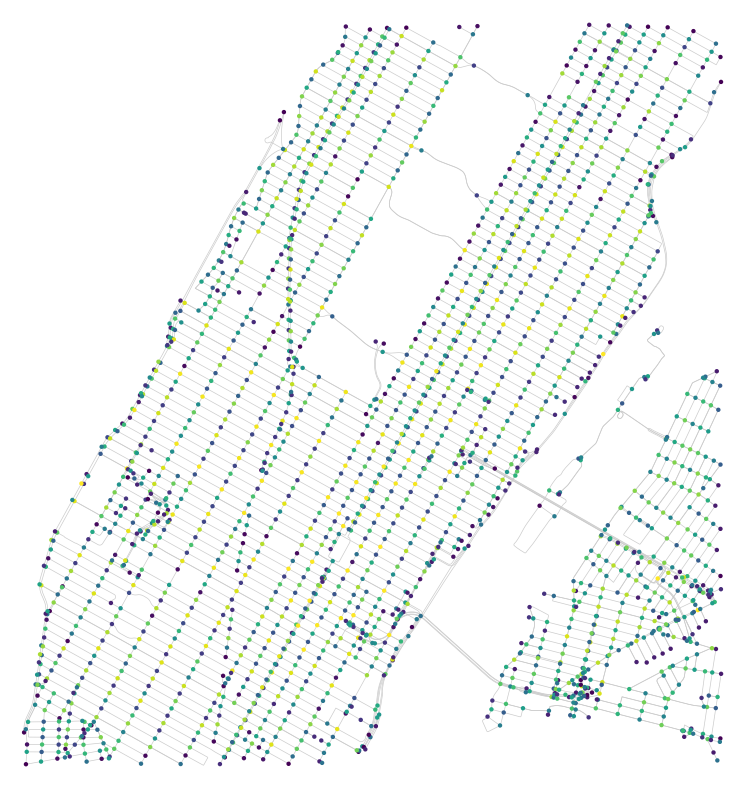

Text(0.5, 1.0, 'Contraction order: dark nodes contracted first')

In [8]:
rank_values = [ch_index.rank[node] for node in G.nodes]
rank_normalizer = plt.Normalize(min(rank_values), max(rank_values))
rank_colormap = plt.colormaps["viridis"]
rank_colors = [rank_colormap(rank_normalizer(value)) for value in rank_values]
fig, ax = ox.plot.plot_graph(
    G,
    node_color=rank_colors,
    node_size=10,
    edge_color="#CCCCCC",
    edge_linewidth=0.5,
    bgcolor="white",
    figsize=(10, 10),
)
ax.set_title("Contraction order: dark nodes contracted first")


## Visualize the optimal route on the street network


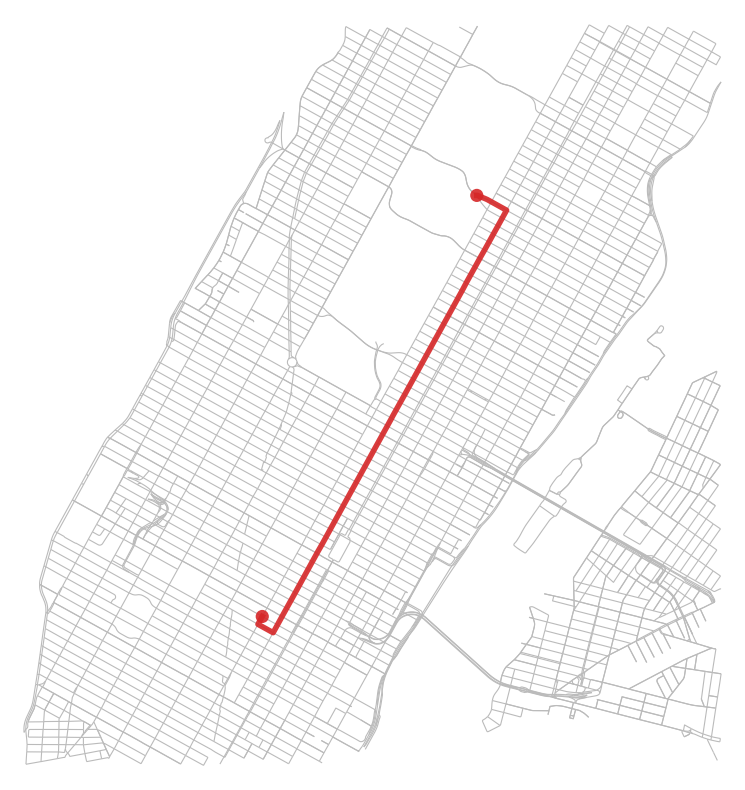

In [9]:
fig, ax = ox.plot.plot_graph_route(
    G,
    route,
    route_color="#D62728",
    route_linewidth=4,
    route_alpha=0.9,
    orig_dest_size=90,
    node_size=0,
    bgcolor="white",
    edge_color="#BBBBBB",
    edge_linewidth=0.8,
    figsize=(10, 10),
)


## Interactive OpenStreetMap route with AntPath


In [10]:
import folium
from folium.plugins import AntPath


def route_coordinates(G, route):
    """Convert an OSMnx route to ordered (latitude, longitude) points."""
    coordinates = []

    for u, v in zip(route[:-1], route[1:]):
        edge = min(
            G.get_edge_data(u, v).values(),
            key=lambda attributes: float(attributes.get("length", math.inf)),
        )
        geometry = edge.get("geometry")

        if geometry is None:
            segment = [
                (G.nodes[u]["y"], G.nodes[u]["x"]),
                (G.nodes[v]["y"], G.nodes[v]["x"]),
            ]
        else:
            segment = [(latitude, longitude) for longitude, latitude in geometry.coords]
            u_point = (G.nodes[u]["y"], G.nodes[u]["x"])
            first_distance = (segment[0][0] - u_point[0]) ** 2 + (
                segment[0][1] - u_point[1]
            ) ** 2
            last_distance = (segment[-1][0] - u_point[0]) ** 2 + (
                segment[-1][1] - u_point[1]
            ) ** 2
            if last_distance < first_distance:
                segment.reverse()

        if coordinates and coordinates[-1] == segment[0]:
            coordinates.extend(segment[1:])
        else:
            coordinates.extend(segment)

    return coordinates


animated_route = route_coordinates(G, route)
route_map = folium.Map(
    location=center,
    tiles="OpenStreetMap",
    zoom_start=14,
    control_scale=True,
)

AntPath(
    locations=animated_route,
    color="#D62728",
    pulse_color="#FFFFFF",
    weight=6,
    opacity=0.9,
    delay=700,
    dash_array=[10, 20],
    tooltip=f"Optimal CH route: {solution.distance:,.1f} m",
).add_to(route_map)

folium.Marker(
    origin_point,
    tooltip="Origin: Empire State Building",
    popup="Empire State Building",
    icon=folium.Icon(color="green", icon="play"),
).add_to(route_map)

folium.Marker(
    destination_point,
    tooltip="Destination: Central Park",
    popup="Central Park",
    icon=folium.Icon(color="red", icon="flag"),
).add_to(route_map)

route_map.fit_bounds(animated_route)
route_map


### Interpretation

- **Preprocessing:** Nodes are contracted in an importance-based order. A shortcut is added only when the removed node provides a shorter connection than every witness path that avoids it.

- **Query:** The forward and backward searches traverse only toward nodes of higher rank. Their best meeting point defines the optimal compressed route.

- **Unpacking:** Every shortcut stores its two component arcs, allowing the complete original OSM route to be reconstructed recursively.

- **Performance:** Preprocessing is worthwhile when the same road graph serves many queries. A single Dijkstra run can be faster if only one route will ever be requested.

This is a compact educational implementation for non-negative distance weights. Production routing engines use additional engineering such as parallel preprocessing, stall-on-demand, nested-dissection ordering, and persistent binary indexes.
